In [1]:
import numpy as np
import matplotlib.pyplot as plt
data = np.load('H:\seismic data\Hint_seismic\dataset\model94\model94_all.npy')

In [2]:
print(data.shape)
print(np.max(data), np.min(data))


(198, 1000, 480)
76097.94 -48385.023


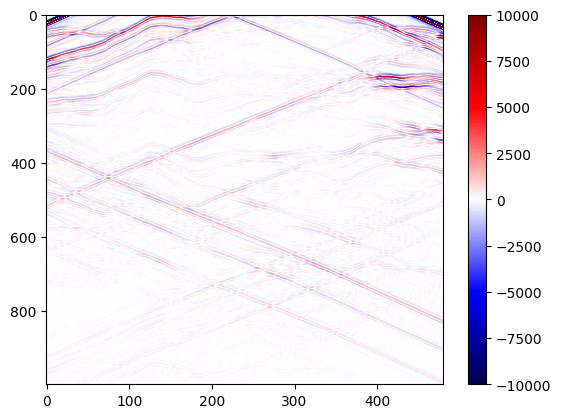

In [17]:
plt.imshow(data[137],aspect='auto',cmap=plt.cm.seismic,vmin =-10000,vmax = 10000)
plt.colorbar()

In [11]:
import os
path_save='F:/GraduateStudent/3.导师/论文/EAAI/Latex Source file/figures/c3'
save_name='Model94_0_shot'
save_type='pdf'
dt_not_use = False
dt = 0.004   # 采样间隔（单位：秒，对应8ms）
trace = data[0]
fig, axs = plt.subplots(nrows=1, ncols=1, facecolor='w', edgecolor='k',  # 背景为白，边框为黑
                        squeeze=False)
axs = axs.ravel()
# 坐标轴位置
axs[0].xaxis.tick_top()
axs[0].xaxis.set_label_position('top')
axs[0].yaxis.tick_left()
axs[0].yaxis.set_label_position('left')

# 设置坐标轴范围
y_range, x_range = trace.shape
# print(y_range, x_range)
num_ticks = 5  # 刻度数量
if dt != None:
    T = dt * y_range
    positions = np.linspace(0, y_range, num_ticks)                  # 从0到总时间T生成等间距刻度位置
    labels = np.round(np.linspace(0, T, num_ticks), 3)        # 直接映射实际时间值，保留3位小数（毫秒级）
if dt_not_use:
    positions = np.linspace(0, y_range, num_ticks)            # 根据图像高度定
    labels = np.round(np.linspace(0, 1, num_ticks), 3)        # 映射为 0 到 1 的刻度标签  0 到 1 之间生成 6 个等间距的数值,保留1位小数
axs[0].set_xlim((0,x_range))
axs[0].set_yticks(positions)
axs[0].set_yticklabels(labels)
axs[0].tick_params(axis='both', labelsize=12)  # 同时设置x/y轴刻度标签大小
# axs[0].invert_yaxis() #翻转y轴

# 设置标签和标题
x_label= 'Trace number'
axs[0].set_xlabel(x_label, fontsize=15)
y_label = 'Time (s)'
axs[0].set_ylabel(y_label, fontsize=15)
title  = ''
axs[0].set_title(title)
plt.imshow(trace,aspect='auto', cmap=plt.cm.seismic, vmin=-10000, vmax = 10000)
plt.colorbar()
plt.savefig(os.path.join(path_save, '{}'.format(save_name) + ".{}".format(save_type)), bbox_inches='tight', pad_inches=0.1) # jpeg
plt.close()